In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import explained_variance_score

In [ ]:
def generate_data(d, m, sigma_sq=1.0):
    np.random.seed(0)

    # Generate random but fixed mean vector, covariance matrix
    mu = np.random.randn(d)
    A = np.random.randn(d, d)
    Sigma = np.dot(A, A.T)
    theta_climate = np.random.randn(d)

    # Generate feature vectors (sensor readings)
    X = np.random.multivariate_normal(mu, Sigma, 2 * m)

    # Generate target values (tomorrow's average temperature)
    y = np.dot(X, theta_climate) + np.random.normal(0, np.sqrt(sigma_sq), 2 * m)

    # Split the dataset
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

    return X_train, y_train, X_test, y_test

####  Experiment 1: Varying m


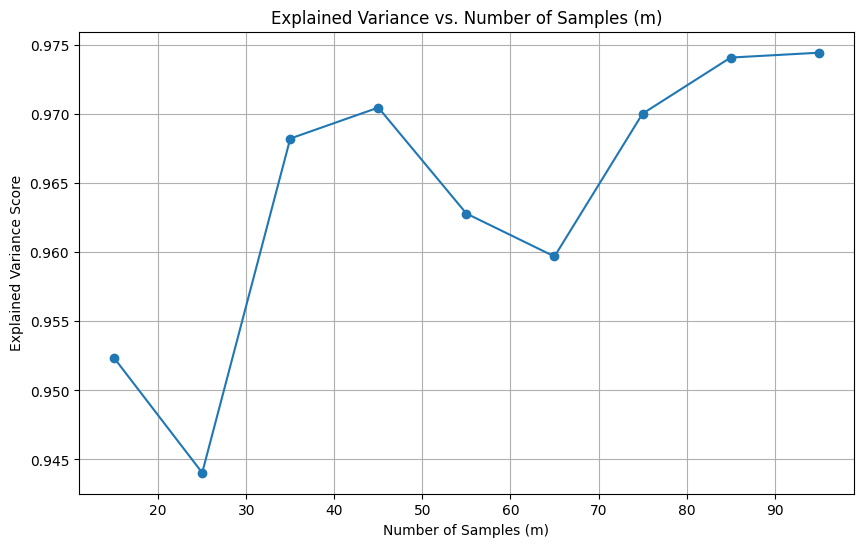

In [ ]:
d_fixed = 10
m_values = range(15, 100, 10)
ev_scores_m = []

for m in m_values:
    try:
        X_train, y_train, X_test, y_test = generate_data(d_fixed, m)

        # Parameter Estimation
        model = LinearRegression()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Performance Evaluation
        ev_score = explained_variance_score(y_test, y_pred)
        ev_scores_m.append(ev_score)
    except np.linalg.LinAlgError:
        print(f"Solver failed for m = {m} (singular matrix).")
        ev_scores_m.append(np.nan)

# Plotting for Experiment 1
plt.figure(figsize=(10, 6))
plt.plot(m_values, ev_scores_m, marker='o')
plt.title('Explained Variance vs. Number of Samples (m)')
plt.xlabel('Number of Samples (m)')
plt.ylabel('Explained Variance Score')
plt.grid(True)

#### Experiment 2: Varying d

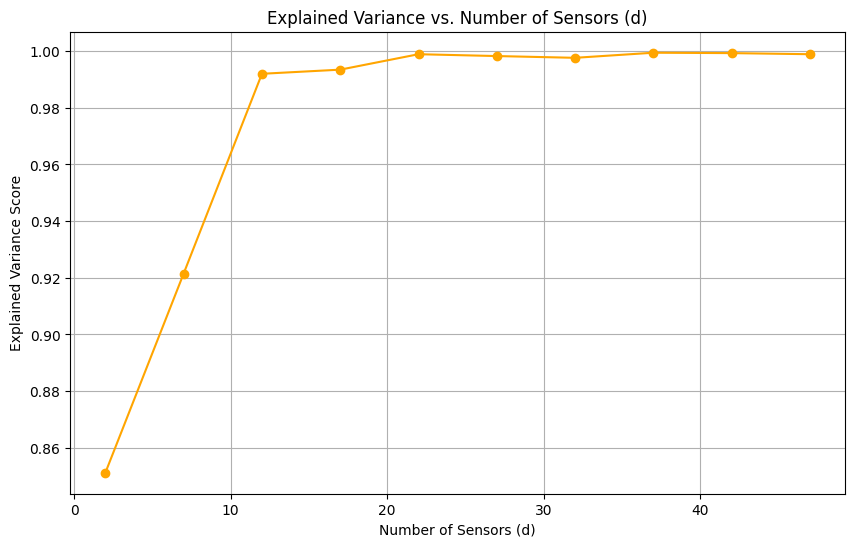

In [ ]:
m_fixed = 200
d_values = range(2, 50, 5)
ev_scores_d = []

for d in d_values:
    try:
        X_train, y_train, X_test, y_test = generate_data(d, m_fixed)

        # Parameter Estimation
        model = LinearRegression()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Performance Evaluation
        ev_score = explained_variance_score(y_test, y_pred)
        ev_scores_d.append(ev_score)
    except np.linalg.LinAlgError:
        print(f"Solver failed for d = {d} (singular matrix).")
        ev_scores_d.append(np.nan)


# Plotting for Experiment 2
plt.figure(figsize=(10, 6))
plt.plot(d_values, ev_scores_d, marker='o', color='orange')
plt.title('Explained Variance vs. Number of Sensors (d)')
plt.xlabel('Number of Sensors (d)')
plt.ylabel('Explained Variance Score')
plt.grid(True)